# NN Quick Test — WNBA Win Probability

Train a simple neural network on the 160 features (7 players × 9 feat × 2 teams + elo + recent form + style + rest).  
Train: 2015-2024 | Test: 2025 OOS.

**XGB benchmarks (2025 OOS):**
| Model | LogLoss | Brier | Acc |
|-------|---------|-------|-----|
| elo | 0.61510 | 0.21317 | 0.66774 |
| xgb | 0.61215 | 0.21123 | 0.67419 |
| logit_162 | 0.61014 | 0.21128 | 0.67419 |
| ensemble | 0.61591 | 0.21322 | 0.66129 |

In [7]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import log_loss, brier_score_loss, accuracy_score

DATA = "../data/gold/features_only/game_features_2015_2025_REGPST.csv"
df = pd.read_csv(DATA)
print(f"Shape: {df.shape}")
print(f"Seasons: {sorted(df['season'].unique())}")
df.head(2)

Shape: (2532, 164)
Seasons: [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,season,home_elo_pre,away_elo_pre,home_win,home_p1_m_ewma_pre,home_p1_q_pre,home_p1_days_since_first_report_pre,home_p1_days_since_last_dnp_pre,home_p1_consec_dnps_pre,home_p1_played_last_game_pre,...,home_games_last_4_days_pre,home_games_last_7_days_pre,home_travel_miles_pre,home_timezone_shift_hours_pre,away_days_rest_pre,away_is_b2b_pre,away_games_last_4_days_pre,away_games_last_7_days_pre,away_travel_miles_pre,away_timezone_shift_hours_pre
0,2015,1505.0,1505.0,0,0.0,0.0,0,0,0,0,...,0,0,0.0,0,0,1,0,0,315.3,0
1,2015,1505.0,1505.0,1,0.0,0.0,0,0,0,0,...,0,0,0.0,0,0,1,0,0,745.9,0


In [8]:
# ── Define feature groups ──────────────────────────────────────────
N_PLAYERS = 7
PLAYER_FEATS = [
    "m_ewma_pre", "q_pre", "days_since_first_report_pre",
    "days_since_last_dnp_pre", "consec_dnps_pre", "played_last_game_pre",
    "minutes_last_game_pre", "days_since_last_played_pre", "injury_present_flag_pre",
]

def player_cols(side, n_players=N_PLAYERS):
    return [f"{side}_p{i}_{f}" for i in range(1, n_players+1) for f in PLAYER_FEATS]

FORM_SUFFIXES = ["net_rtg_ewma_pre", "efg_ewma_pre", "tov_pct_ewma_pre", "orb_pct_ewma_pre", "ftr_ewma_pre"]
STYLE_SUFFIXES = ["off_3pa_rate_pre", "def_3pa_allowed_pre", "off_2pa_rate_pre", "def_2pa_allowed_pre", "off_tov_pct_pre", "def_forced_tov_pre"]
REST_SUFFIXES = ["days_rest_pre", "is_b2b_pre", "games_last_4_days_pre", "games_last_7_days_pre", "travel_miles_pre", "timezone_shift_hours_pre"]

elo_cols    = ["home_elo_pre", "away_elo_pre"]
home_player = player_cols("home")
away_player = player_cols("away")
home_form   = [f"home_{s}" for s in FORM_SUFFIXES]
away_form   = [f"away_{s}" for s in FORM_SUFFIXES]
home_style  = [f"home_{s}" for s in STYLE_SUFFIXES]
away_style  = [f"away_{s}" for s in STYLE_SUFFIXES]
home_rest   = [f"home_{s}" for s in REST_SUFFIXES]
away_rest   = [f"away_{s}" for s in REST_SUFFIXES]

all_features = elo_cols + home_player + away_player + home_form + away_form + home_style + away_style + home_rest + away_rest

# Sanity check: no overlaps
assert len(all_features) == len(set(all_features)), "Duplicate features!"
for c in all_features:
    assert c in df.columns, f"Missing column: {c}"

print(f"Elo: {len(elo_cols)}, Player: {len(home_player)}+{len(away_player)}, "
      f"Form: {len(home_form)}+{len(away_form)}, Style: {len(home_style)}+{len(away_style)}, "
      f"Rest: {len(home_rest)}+{len(away_rest)}")
print(f"Total features: {len(all_features)}")

Elo: 2, Player: 63+63, Form: 5+5, Style: 6+6, Rest: 6+6
Total features: 162


In [9]:
# ── Train/test split & scale ───────────────────────────────────────
train = df[df["season"] <= 2024].copy()
test  = df[df["season"] == 2025].copy()
print(f"Train: {len(train)} games (2015-2024), Test: {len(test)} games (2025)")

X_train_raw = train[all_features].fillna(0).values.astype(np.float32)
X_test_raw  = test[all_features].fillna(0).values.astype(np.float32)
y_train = train["home_win"].values.astype(np.float32)
y_test  = test["home_win"].values.astype(np.float32)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test  = scaler.transform(X_test_raw)

Train: 2222 games (2015-2024), Test: 310 games (2025)


In [10]:
# ── Build structured input tensors ─────────────────────────────────
# Slice indices for each feature group (in all_features order)
def get_slice(cols):
    idxs = [all_features.index(c) for c in cols]
    return min(idxs), max(idxs) + 1

slices = {
    "elo":         get_slice(elo_cols),
    "home_player": get_slice(home_player),
    "away_player": get_slice(away_player),
    "home_form":   get_slice(home_form),
    "away_form":   get_slice(away_form),
    "home_style":  get_slice(home_style),
    "away_style":  get_slice(away_style),
    "home_rest":   get_slice(home_rest),
    "away_rest":   get_slice(away_rest),
}
for k, (s, e) in slices.items():
    print(f"{k:15s}: cols [{s:3d}:{e:3d}] → {e-s} features")

elo            : cols [  0:  2] → 2 features
home_player    : cols [  2: 65] → 63 features
away_player    : cols [ 65:128] → 63 features
home_form      : cols [128:133] → 5 features
away_form      : cols [133:138] → 5 features
home_style     : cols [138:144] → 6 features
away_style     : cols [144:150] → 6 features
home_rest      : cols [150:156] → 6 features
away_rest      : cols [156:162] → 6 features


In [11]:
# ── NN Model with structured sub-networks ─────────────────────────
class WNBANet(nn.Module):
    """
    Separate sub-networks for each feature group, merged for final prediction.
    - Player encoder: shared MLP across 7 player slots, then pooled per team
    - Team-level branches: small MLPs for form, style, rest
    - Elo passed through directly
    """
    def __init__(self, n_player_feats=9, n_form=5, n_style=6, n_rest=6,
                 player_hidden=32, team_hidden=16, merge_hidden=64, dropout=0.3):
        super().__init__()
        # Shared player encoder (applied per-slot)
        self.player_enc = nn.Sequential(
            nn.Linear(n_player_feats, player_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(player_hidden, player_hidden),
            nn.ReLU(),
        )
        # Team-level branches
        self.form_enc = nn.Sequential(
            nn.Linear(n_form, team_hidden), nn.ReLU(), nn.Dropout(dropout))
        self.style_enc = nn.Sequential(
            nn.Linear(n_style, team_hidden), nn.ReLU(), nn.Dropout(dropout))
        self.rest_enc = nn.Sequential(
            nn.Linear(n_rest, team_hidden), nn.ReLU(), nn.Dropout(dropout))

        # Merge: 2×player_hidden (home+away pooled) + 2×3×team_hidden (form,style,rest per team) + 2 (elo)
        merge_in = 2 * player_hidden + 2 * 3 * team_hidden + 2
        self.head = nn.Sequential(
            nn.Linear(merge_in, merge_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(merge_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def _encode_players(self, x_players):
        """x_players: (batch, n_players * n_feats) → (batch, player_hidden) via mean pool"""
        batch = x_players.size(0)
        x = x_players.view(batch, N_PLAYERS, -1)          # (B, 7, 9)
        x = self.player_enc(x)                              # (B, 7, H)
        return x.mean(dim=1)                                # (B, H)

    def forward(self, x):
        s = slices
        elo        = x[:, s["elo"][0]:s["elo"][1]]
        home_pl    = self._encode_players(x[:, s["home_player"][0]:s["home_player"][1]])
        away_pl    = self._encode_players(x[:, s["away_player"][0]:s["away_player"][1]])
        home_fm    = self.form_enc(x[:, s["home_form"][0]:s["home_form"][1]])
        away_fm    = self.form_enc(x[:, s["away_form"][0]:s["away_form"][1]])
        home_st    = self.style_enc(x[:, s["home_style"][0]:s["home_style"][1]])
        away_st    = self.style_enc(x[:, s["away_style"][0]:s["away_style"][1]])
        home_rs    = self.rest_enc(x[:, s["home_rest"][0]:s["home_rest"][1]])
        away_rs    = self.rest_enc(x[:, s["away_rest"][0]:s["away_rest"][1]])

        merged = torch.cat([elo, home_pl, away_pl, home_fm, away_fm,
                            home_st, away_st, home_rs, away_rs], dim=1)
        return self.head(merged).squeeze(-1)

model = WNBANet()
total_params = sum(p.numel() for p in model.parameters())
print(f"Model params: {total_params:,}")
print(model)

Model params: 14,241
WNBANet(
  (player_enc): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
  )
  (form_enc): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (style_enc): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (rest_enc): Sequential(
    (0): Linear(in_features=6, out_features=16, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (head): Sequential(
    (0): Linear(in_features=162, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )

In [12]:
# ── Training loop ─────────────────────────────────────────────────
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

X_tr_t = torch.tensor(X_train, dtype=torch.float32)
y_tr_t = torch.tensor(y_train, dtype=torch.float32)
X_te_t = torch.tensor(X_test,  dtype=torch.float32)
y_te_t = torch.tensor(y_test,  dtype=torch.float32)

train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=128, shuffle=True)

model = WNBANet().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=15, factor=0.5)
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 300
best_test_loss = float("inf")
best_state = None
history = []

for epoch in range(1, EPOCHS + 1):
    model.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = criterion(logits, yb)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(xb)
    train_loss = epoch_loss / len(train_ds)

    # Eval on test
    model.eval()
    with torch.no_grad():
        test_logits = model(X_te_t.to(device))
        test_loss = criterion(test_logits, y_te_t.to(device)).item()
        test_probs = torch.sigmoid(test_logits).cpu().numpy()

    scheduler.step(test_loss)
    history.append({"epoch": epoch, "train_loss": train_loss, "test_loss": test_loss})

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_epoch = epoch

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train_loss={train_loss:.5f} | test_loss={test_loss:.5f} | lr={optimizer.param_groups[0]['lr']:.1e}")

print(f"\nBest test loss: {best_test_loss:.5f} at epoch {best_epoch}")

Device: cpu
Epoch   1 | train_loss=0.68409 | test_loss=0.67816 | lr=1.0e-03
Epoch  50 | train_loss=0.57222 | test_loss=0.61550 | lr=2.5e-04
Epoch 100 | train_loss=0.56482 | test_loss=0.61654 | lr=3.1e-05
Epoch 150 | train_loss=0.56978 | test_loss=0.61722 | lr=3.9e-06
Epoch 200 | train_loss=0.56371 | test_loss=0.61738 | lr=4.9e-07
Epoch 250 | train_loss=0.56454 | test_loss=0.61738 | lr=3.1e-08
Epoch 300 | train_loss=0.57110 | test_loss=0.61738 | lr=1.5e-08

Best test loss: 0.60721 at epoch 10


In [13]:
# ── Evaluate best model ───────────────────────────────────────────
model.load_state_dict(best_state)
model.eval()
with torch.no_grad():
    logits = model(X_te_t.to(device))
    probs = torch.sigmoid(logits).cpu().numpy()

nn_logloss = log_loss(y_test, probs)
nn_brier   = brier_score_loss(y_test, probs)
nn_acc     = accuracy_score(y_test, (probs >= 0.5).astype(int))

print(f"\n{'Model':<15s} {'LogLoss':>8s} {'Brier':>8s} {'Acc':>8s}")
print("-" * 42)
for name, ll, br, ac in [
    ("elo",        0.61510, 0.21317, 0.66774),
    ("xgb",        0.61215, 0.21123, 0.67419),
    ("logit_162",   0.61014, 0.21128, 0.67419),
    ("ensemble",   0.61591, 0.21322, 0.66129),
    ("NN (ours)",  nn_logloss, nn_brier, nn_acc),
]:
    print(f"{name:<15s} {ll:>8.5f} {br:>8.5f} {ac:>8.5f}")


Model            LogLoss    Brier      Acc
------------------------------------------
elo              0.61510  0.21317  0.66774
xgb              0.61215  0.21123  0.67419
logit_162        0.61014  0.21128  0.67419
ensemble         0.61591  0.21322  0.66129
NN (ours)        0.60721  0.21062  0.66129


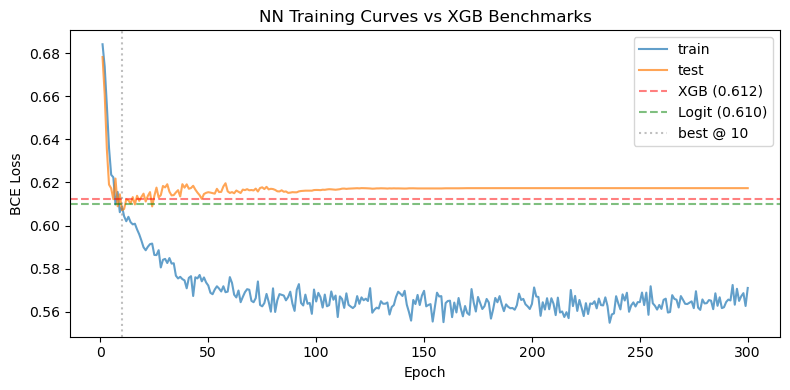

In [14]:
# ── Training curves ───────────────────────────────────────────────
import matplotlib.pyplot as plt

hist = pd.DataFrame(history)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist["epoch"], hist["train_loss"], label="train", alpha=0.7)
ax.plot(hist["epoch"], hist["test_loss"],  label="test",  alpha=0.7)
ax.axhline(0.61215, color="red", ls="--", alpha=0.5, label="XGB (0.612)")
ax.axhline(0.61014, color="green", ls="--", alpha=0.5, label="Logit (0.610)")
ax.axvline(best_epoch, color="gray", ls=":", alpha=0.5, label=f"best @ {best_epoch}")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title("NN Training Curves vs XGB Benchmarks")
ax.legend(); plt.tight_layout(); plt.show()

## V2: Two Vectors-of-Vectors (Home vs Away)

Each team side is encoded as a **sequence of sub-vectors**:
- 7 player-slot embeddings (shared player encoder → H)
- 1 form embedding (form encoder → H)
- 1 style embedding (style encoder → H)
- 1 rest embedding (rest encoder → H)

→ **(batch, 10, H) per team**, then self-attention pooling within each team, plus elo → merge head.

In [15]:
# ── V2 Model: Two Vectors-of-Vectors ─────────────────────────────

class AttentionPool(nn.Module):
    """Learnable weighted average over a sequence dim."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x: (B, S, H) → (B, H)
        w = torch.softmax(self.attn(x), dim=1)  # (B, S, 1)
        return (w * x).sum(dim=1)                # (B, H)


class WNBANetV2(nn.Module):
    """
    Each team → 10 sub-vectors (7 players + form + style + rest),
    each projected to hidden_dim H. Attention-pooled per team, then merged.
    Shared encoders across home/away.
    """
    def __init__(self, n_player_feats=9, n_form=5, n_style=6, n_rest=6,
                 hidden=32, merge_hidden=64, dropout=0.3):
        super().__init__()
        # Sub-vector encoders (all project to same hidden dim)
        self.player_enc = nn.Sequential(
            nn.Linear(n_player_feats, hidden), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(hidden, hidden), nn.ReLU(),
        )
        self.form_enc = nn.Sequential(
            nn.Linear(n_form, hidden), nn.ReLU(), nn.Dropout(dropout))
        self.style_enc = nn.Sequential(
            nn.Linear(n_style, hidden), nn.ReLU(), nn.Dropout(dropout))
        self.rest_enc = nn.Sequential(
            nn.Linear(n_rest, hidden), nn.ReLU(), nn.Dropout(dropout))

        # Attention pool per team (10 sub-vectors → 1 team embedding)
        self.team_attn = AttentionPool(hidden)

        # Merge: home_embed (H) + away_embed (H) + elo (2)
        self.head = nn.Sequential(
            nn.Linear(2 * hidden + 2, merge_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(merge_hidden, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )

    def _encode_team(self, x_player, x_form, x_style, x_rest):
        """Build (B, 10, H) sequence for one team, then attention-pool to (B, H)."""
        B = x_player.size(0)
        # Player slots: (B, 7*9) → (B, 7, 9) → (B, 7, H)
        players = self.player_enc(x_player.view(B, N_PLAYERS, -1))
        # Team-level: each (B, F) → (B, 1, H)
        form  = self.form_enc(x_form).unsqueeze(1)
        style = self.style_enc(x_style).unsqueeze(1)
        rest  = self.rest_enc(x_rest).unsqueeze(1)
        # Stack: (B, 10, H)
        team_seq = torch.cat([players, form, style, rest], dim=1)
        return self.team_attn(team_seq)  # (B, H)

    def forward(self, x):
        s = slices
        elo = x[:, s["elo"][0]:s["elo"][1]]

        home_embed = self._encode_team(
            x[:, s["home_player"][0]:s["home_player"][1]],
            x[:, s["home_form"][0]:s["home_form"][1]],
            x[:, s["home_style"][0]:s["home_style"][1]],
            x[:, s["home_rest"][0]:s["home_rest"][1]],
        )
        away_embed = self._encode_team(
            x[:, s["away_player"][0]:s["away_player"][1]],
            x[:, s["away_form"][0]:s["away_form"][1]],
            x[:, s["away_style"][0]:s["away_style"][1]],
            x[:, s["away_rest"][0]:s["away_rest"][1]],
        )

        merged = torch.cat([elo, home_embed, away_embed], dim=1)
        return self.head(merged).squeeze(-1)

model_v2 = WNBANetV2()
total_params_v2 = sum(p.numel() for p in model_v2.parameters())
print(f"V2 Model params: {total_params_v2:,}")
print(model_v2)

V2 Model params: 8,450
WNBANetV2(
  (player_enc): Sequential(
    (0): Linear(in_features=9, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=32, out_features=32, bias=True)
    (4): ReLU()
  )
  (form_enc): Sequential(
    (0): Linear(in_features=5, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (style_enc): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (rest_enc): Sequential(
    (0): Linear(in_features=6, out_features=32, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
  )
  (team_attn): AttentionPool(
    (attn): Linear(in_features=32, out_features=1, bias=True)
  )
  (head): Sequential(
    (0): Linear(in_features=66, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
  

In [16]:
# ── V2 Training loop ──────────────────────────────────────────────
model_v2 = WNBANetV2().to(device)
optimizer_v2 = torch.optim.Adam(model_v2.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler_v2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_v2, patience=15, factor=0.5)

best_test_loss_v2 = float("inf")
best_state_v2 = None
history_v2 = []

for epoch in range(1, EPOCHS + 1):
    model_v2.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        xb, yb = xb.to(device), yb.to(device)
        logits = model_v2(xb)
        loss = criterion(logits, yb)
        optimizer_v2.zero_grad()
        loss.backward()
        optimizer_v2.step()
        epoch_loss += loss.item() * len(xb)
    train_loss = epoch_loss / len(train_ds)

    model_v2.eval()
    with torch.no_grad():
        test_logits = model_v2(X_te_t.to(device))
        test_loss = criterion(test_logits, y_te_t.to(device)).item()

    scheduler_v2.step(test_loss)
    history_v2.append({"epoch": epoch, "train_loss": train_loss, "test_loss": test_loss})

    if test_loss < best_test_loss_v2:
        best_test_loss_v2 = test_loss
        best_state_v2 = {k: v.cpu().clone() for k, v in model_v2.state_dict().items()}
        best_epoch_v2 = epoch

    if epoch % 50 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d} | train={train_loss:.5f} | test={test_loss:.5f} | lr={optimizer_v2.param_groups[0]['lr']:.1e}")

print(f"\nV2 Best test loss: {best_test_loss_v2:.5f} at epoch {best_epoch_v2}")

Epoch   1 | train=0.69034 | test=0.67514 | lr=1.0e-03
Epoch  50 | train=0.58664 | test=0.62475 | lr=2.5e-04
Epoch 100 | train=0.58897 | test=0.62767 | lr=3.1e-05
Epoch 150 | train=0.57976 | test=0.62847 | lr=3.9e-06
Epoch 200 | train=0.58077 | test=0.62852 | lr=4.9e-07
Epoch 250 | train=0.57865 | test=0.62853 | lr=6.1e-08
Epoch 300 | train=0.58275 | test=0.62853 | lr=1.5e-08

V2 Best test loss: 0.60649 at epoch 12


In [18]:
# ── V2 Evaluate & Compare ─────────────────────────────────────────
model_v2.load_state_dict(best_state_v2)
model_v2.eval()
with torch.no_grad():
    probs_v2 = torch.sigmoid(model_v2(X_te_t.to(device))).cpu().numpy()

v2_logloss = log_loss(y_test, probs_v2)
v2_brier   = brier_score_loss(y_test, probs_v2)
v2_acc     = accuracy_score(y_test, (probs_v2 >= 0.5).astype(int))

print(f"\n{'Model':<15s} {'LogLoss':>8s} {'Brier':>8s} {'Acc':>8s}")
print("-" * 42)
for name, ll, br, ac in [
    ("elo",        0.61510, 0.21317, 0.66774),
    ("xgb",        0.61215, 0.21123, 0.67419),
    ("logit_162",  0.61014, 0.21128, 0.67419),
    ("ensemble",   0.61591, 0.21322, 0.66129),
    ("NN v1",      nn_logloss, nn_brier, nn_acc),
    ("NN v2 (VoV)", v2_logloss, v2_brier, v2_acc),
]:
    print(f"{name:<15s} {ll:>8.5f} {br:>8.5f} {ac:>8.5f}")


Model            LogLoss    Brier      Acc
------------------------------------------
elo              0.61510  0.21317  0.66774
xgb              0.61215  0.21123  0.67419
logit_162        0.61014  0.21128  0.67419
ensemble         0.61591  0.21322  0.66129
NN v1            0.60721  0.21062  0.66129
NN v2 (VoV)      0.60649  0.20966  0.67419


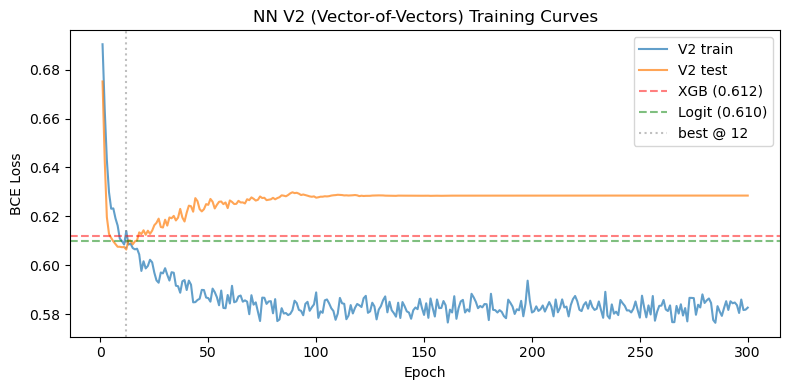

In [19]:
# ── V2 Training curves ────────────────────────────────────────────
hist_v2 = pd.DataFrame(history_v2)
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hist_v2["epoch"], hist_v2["train_loss"], label="V2 train", alpha=0.7)
ax.plot(hist_v2["epoch"], hist_v2["test_loss"],  label="V2 test",  alpha=0.7)
ax.axhline(0.61215, color="red", ls="--", alpha=0.5, label="XGB (0.612)")
ax.axhline(0.61014, color="green", ls="--", alpha=0.5, label="Logit (0.610)")
ax.axvline(best_epoch_v2, color="gray", ls=":", alpha=0.5, label=f"best @ {best_epoch_v2}")
ax.set_xlabel("Epoch"); ax.set_ylabel("BCE Loss")
ax.set_title("NN V2 (Vector-of-Vectors) Training Curves")
ax.legend(); plt.tight_layout(); plt.show()